# Book - Modern Time Series Forecasting with Python

## Chapter 04 - Autoregressive (AR) Models

### Python version 3.8

### Libraries version
* matplotlib: 3.7.1
* pandas: 2.0.3
* numpy: 1.24.4
* statsmodels: 0.14.1
* sklearn: 1.3.2
* scipy: 1.10.1

### AR modeling in Python

#### Loading libries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg, ar_select_order
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from sklearn.metrics import mean_absolute_error, mean_squared_error
import scipy.stats as stats


import warnings
warnings.filterwarnings('ignore')

#### Load the Dataset

In [2]:
sunspots = sm.datasets.sunspots.load_pandas().data['SUNACTIVITY']
sunspots.index = pd.Index(sm.tsa.datetools.dates_from_range('1700', '2008'))

#### Visualize Data

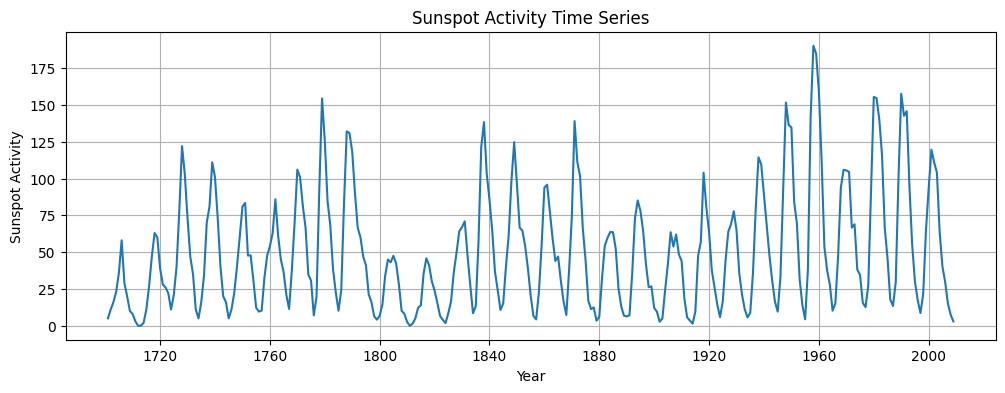

In [3]:
plt.figure(figsize=(12, 4))
plt.plot(sunspots)
plt.title('Sunspot Activity Time Series')
plt.xlabel('Year')
plt.ylabel('Sunspot Activity')
plt.grid(True)
plt.show()

#### Check stationarity (ADF Test - assuming constant mean)

In [4]:
# Check stationarity (ADF Test - assuming constant mean)
print("\n--- Stationarity Check (ADF) ---")
adf_result = adfuller(sunspots, regression='c')
print(f'ADF p-value: {adf_result[1]:.4f}')
if adf_result[1] > 0.05:
    print("ADF test suggests non-stationarity. Differencing might be needed.")
else:
    print("ADF test suggests stationarity.")


--- Stationarity Check (ADF) ---
ADF p-value: 0.0531
ADF test suggests non-stationarity. Differencing might be needed.


#### Check stationarity (KPSS Test - testing for level stationarity)

In [5]:
# Check stationarity (KPSS Test - testing for level stationarity)
print("\n--- Stationarity Check (KPSS) ---")
kpss_result = kpss(sunspots, regression='c', nlags='auto')
print(f'KPSS p-value: {kpss_result[1]:.4f}')
if kpss_result[1] <= 0.05:
    print("KPSS test suggests non-stationarity (rejects H0 of stationarity).")
else:
    print("KPSS test suggests stationarity (fails to reject H0).")


--- Stationarity Check (KPSS) ---
KPSS p-value: 0.0163
KPSS test suggests non-stationarity (rejects H0 of stationarity).


#### Difference the Series to Achieve Stationarity

In [6]:
# Difference the Series to Achieve Stationarity
sunspots_diff = sunspots.diff().dropna()

#### ACF and PACF Plots


--- Select AR Order (p) ---


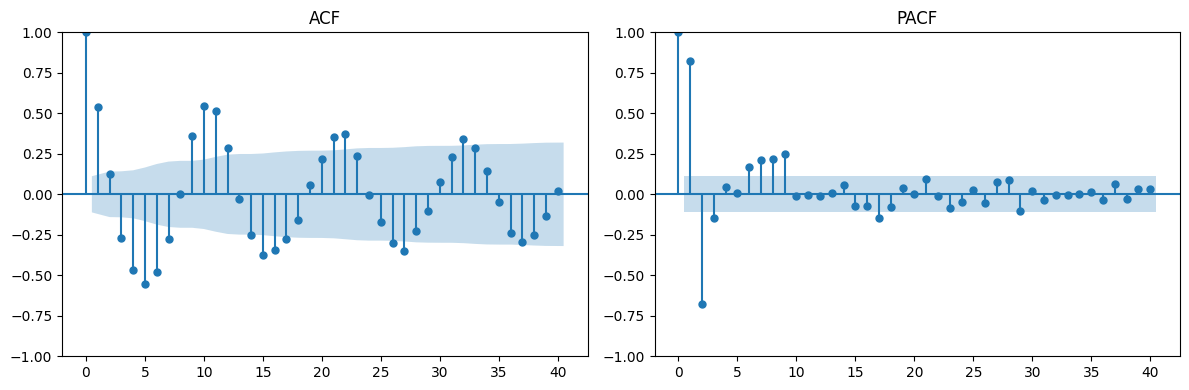

In [7]:
print("\n--- Select AR Order (p) ---")
# Plot ACF and PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(sunspots_diff, lags=40, ax=axes[0])
axes[0].set_title('ACF')
plot_pacf(sunspots, lags=40, ax=axes[1], method='ywm') # Yule-Walker method
axes[1].set_title('PACF')
plt.tight_layout()
plt.show()

In [8]:
# Use ar_select_order (e.g., based on BIC)
selector = ar_select_order(sunspots_diff, maxlag=20, ic='bic', old_names=False)
selected_order = selector.ar_lags
print(selected_order)
p= max(selected_order)

[1, 2, 3, 4, 5, 6, 7, 8]


#### Fit the AR(p) Model

In [9]:
print(f"\n--- Fit AR({p}) Model ---")
model = AutoReg(sunspots, lags=p, trend='c') # Constant trend
results = model.fit()
print("\n--- Examine Model Results --\n\n")
print(results.summary())


--- Fit AR(8) Model ---

--- Examine Model Results --


                            AutoReg Model Results                             
Dep. Variable:            SUNACTIVITY   No. Observations:                  309
Model:                     AutoReg(8)   Log Likelihood               -1249.173
Method:               Conditional MLE   S.D. of innovations             15.350
Date:                Sun, 07 Dec 2025   AIC                           2518.346
Time:                        09:50:13   BIC                           2555.417
Sample:                    12-31-1708   HQIC                          2533.180
                         - 12-31-2008                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              8.5264      2.442      3.492      0.000       3.741      13.312
SUNACTIVITY.L1     1.2229      0.056     21.727      0.000    

#### Diagnose Residuals


--- Diagnose Residuals ---


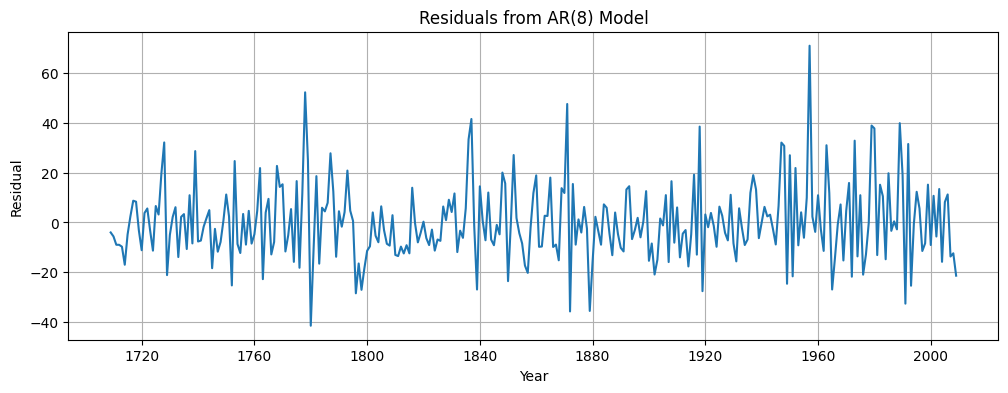

In [10]:
print("\n--- Diagnose Residuals ---")
residuals = results.resid

# Plot residuals
plt.figure(figsize=(12, 4))
plt.plot(residuals)
plt.title(f'Residuals from AR({p}) Model')
plt.xlabel('Year')
plt.ylabel('Residual')
plt.grid(True)
plt.show()


#### Plot ACF/PACF of residuals

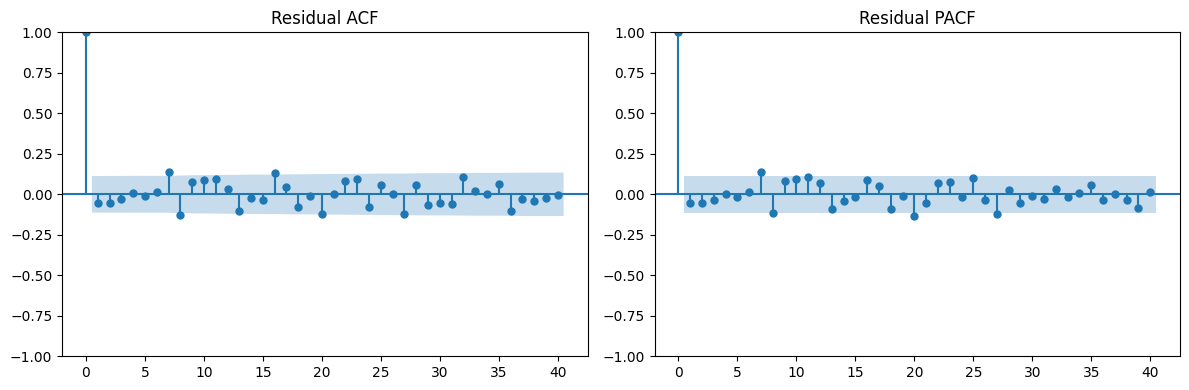

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(residuals, lags=40, ax=axes[0])
axes[0].set_title('Residual ACF')
plot_pacf(residuals, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('Residual PACF')
plt.tight_layout()
plt.show()

#### Ljung-Box test on residuals

In [12]:
print("\n--- Ljung-Box Test on Residuals ---")
lb_test = acorr_ljungbox(residuals, lags=[min(2*p, len(residuals)//5)], return_df=True) # Test lags up to 2p or T/5
print(lb_test)
if lb_test['lb_pvalue'].iloc[0] <= 0.05:
    print("Ljung-Box test suggests significant autocorrelation in residuals (model may be inadequate).")
else:
    print("Ljung-Box test suggests residuals are uncorrelated (model appears adequate).")



--- Ljung-Box Test on Residuals ---
      lb_stat  lb_pvalue
16  30.254351   0.016727
Ljung-Box test suggests significant autocorrelation in residuals (model may be inadequate).


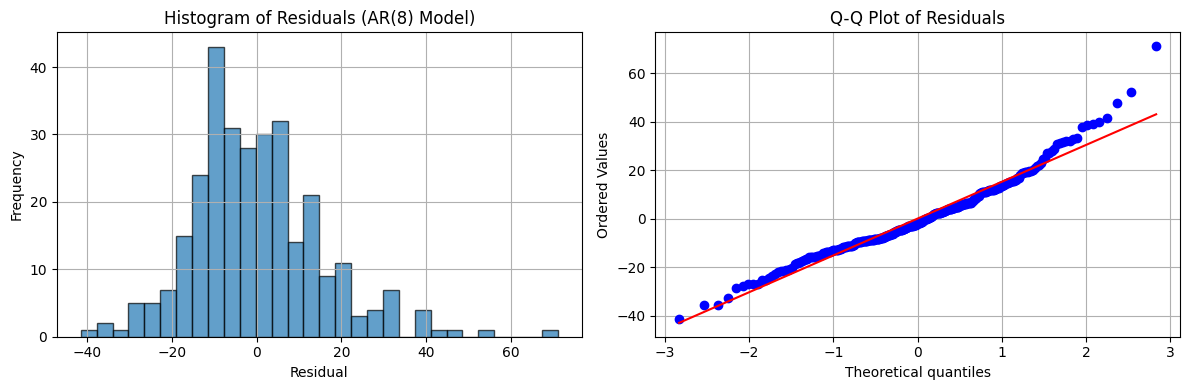

In [13]:
# Create side-by-side plots
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

# Histogram of residuals
axs[0].hist(results.resid, bins=30, edgecolor='black', alpha=0.7)
axs[0].set_title('Histogram of Residuals (AR(8) Model)')
axs[0].set_xlabel('Residual')
axs[0].set_ylabel('Frequency')
axs[0].grid(True)

# Q-Q plot of residuals
stats.probplot(results.resid, dist="norm", plot=axs[1])
axs[1].set_title('Q-Q Plot of Residuals')
axs[1].grid(True)

plt.tight_layout()

plt.show()

In [14]:
jb_stat, jb_pvalue, _, _ = jarque_bera(results.resid)
print(f"Jarque-Bera test p-value: {jb_pvalue:.4f}")

Jarque-Bera test p-value: 0.0000


#### Generate Forecasts


--- Generate Forecasts ---

--- Visualize Results ---


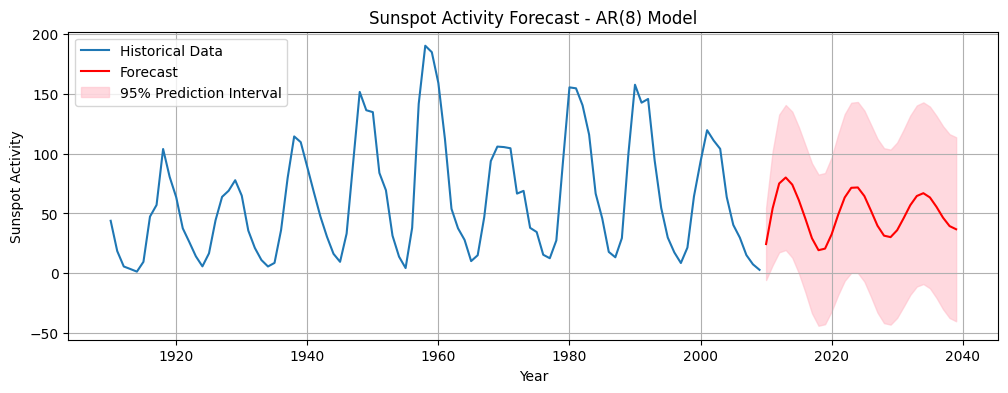

In [15]:
# --- Generate Forecasts ---
print("\n--- Generate Forecasts ---")
forecast_steps = 30 # Forecast next 30 years
forecast_start = len(sunspots)
forecast_end = len(sunspots) + forecast_steps - 1

forecast_obj = results.get_prediction(start=forecast_start, end=forecast_end)
predicted_mean = forecast_obj.predicted_mean
conf_int = forecast_obj.conf_int(alpha=0.05) # 95% prediction intervals

# --- Visualize Results ---
print("\n--- Visualize Results ---")
plt.figure(figsize=(12, 4))

# Plot historical data
plt.plot(sunspots.index[-100:], sunspots.iloc[-100:], label='Historical Data') # Plot last 100 points

# Plot forecasts
plt.plot(predicted_mean.index, predicted_mean, label='Forecast', color='red')

# Plot prediction intervals
plt.fill_between(conf_int.index,
                 conf_int.iloc[:, 0], # lower bound
                 conf_int.iloc[:, 1], # upper bound
                 color='pink', alpha=0.6, label='95% Prediction Interval')

plt.title(f'Sunspot Activity Forecast - AR({p}) Model')
plt.xlabel('Year')
plt.ylabel('Sunspot Activity')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()


In [16]:
# Assume actual values are available for comparison (e.g., first 30 future years)
y_true = sunspots_diff[-30:]  # Substitute with actual future values if available
y_pred = predicted_mean[:30]  # Corresponding model forecasts

mae = mean_absolute_error(y_true, y_pred)
rmse = mean_squared_error(y_true, y_pred, squared=False)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")

MAE: 61.49
RMSE: 69.83
